In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path



In [6]:
# Define paths
DATA_PATH = Path("../../data/raw")

In [8]:
# Load data
df = pd.read_excel(DATA_PATH / "2020_Birth_Final.xlsx")

In [11]:
list(df.columns)

['Registered_Year',
 'Registered_Month2.0',
 'Registered_Month',
 'Registered_District',
 'Birh_Year',
 'Birth_Month.0',
 'Birth_Month',
 'Gender',
 'Hospital or Not',
 'Multiple_Birth_Status',
 'Birth_Weight(grams)',
 'Birth_Order',
 'Birth_Order - Copy',
 'Age of Mother',
 'Marital_Status',
 'District_of_Mother',
 'Race_of_Mother',
 'Race_of_Father']

In [12]:


# ============================================
# FOCUS ON BIRTH WEIGHT - CHANGE THIS VARIABLE NAME TO ANALYZE OTHER VARIABLES
# ============================================
TARGET_VARIABLE = 'Birth_Weight(grams)'  # <-- CHANGE THIS to analyze other variables
# ============================================

print(f"\n{'='*70}")
print(f"📊 MISSING DATA BIAS ANALYSIS FOR: '{TARGET_VARIABLE}'")
print(f"{'='*70}")

# Check if variable exists
if TARGET_VARIABLE not in df.columns:
    print(f"❌ ERROR: Variable '{TARGET_VARIABLE}' not found!")
    print(f"Available columns: {list(df.columns)[:20]}...")
    exit()

# Get missing info
missing_count = df[TARGET_VARIABLE].isnull().sum()
missing_pct = (missing_count / len(df)) * 100
complete_count = len(df) - missing_count
complete_pct = 100 - missing_pct

print(f"\n📌 BASIC INFORMATION:")
print(f"   • Total Records: {len(df):,}")
print(f"   • Missing in {TARGET_VARIABLE}: {missing_count:,} ({missing_pct:.2f}%)")
print(f"   • Complete cases: {complete_count:,} ({complete_pct:.2f}%)")

# ============================================
# STEP 1: CREATE SEPARATE DATASETS
# ============================================

print(f"\n📌 STEP 1: CREATING SEPARATE DATASETS")
print("-" * 50)

# Dataset 1: Records with missing birth weight
missing_data = df[df[TARGET_VARIABLE].isnull()]

# Dataset 2: Records with complete birth weight
complete_data = df[df[TARGET_VARIABLE].notnull()]

print(f"   • Missing records: {len(missing_data):,}")
print(f"   • Complete records: {len(complete_data):,}")

# Save to Excel file
filename = f'missing_analysis_{TARGET_VARIABLE}.xlsx'

with pd.ExcelWriter(filename, engine='openpyxl') as writer:
    # Sheet 1: All records with missing birth weight
    missing_data.to_excel(writer, sheet_name=f'Missing_{TARGET_VARIABLE}', index=False)
    
    # Sheet 2: All records with complete birth weight
    complete_data.to_excel(writer, sheet_name=f'Complete_{TARGET_VARIABLE}', index=False)
    
    # Sheet 3: Summary statistics
    summary = pd.DataFrame({
        'Metric': [
            'Variable Name',
            'Total Records',
            f'Missing in {TARGET_VARIABLE}',
            'Missing %',
            f'Complete {TARGET_VARIABLE}',
            'Complete %'
        ],
        'Value': [
            TARGET_VARIABLE,
            f"{len(df):,}",
            f"{missing_count:,}",
            f"{missing_pct:.2f}%",
            f"{complete_count:,}",
            f"{complete_pct:.2f}%"
        ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print(f"✅ Created: {filename}")

# ============================================
# STEP 2: COMPARE MISSING VS COMPLETE GROUPS
# ============================================

print(f"\n📌 STEP 2: BIAS ANALYSIS - COMPARING GROUPS")
print("-" * 70)

bias_results = []

# Compare NUMERIC variables
print(f"\n🔍 Comparing NUMERIC variables between groups:")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for num_col in numeric_cols:
    if num_col != TARGET_VARIABLE:
        # Get means for both groups (ignoring missing in the comparison variable)
        missing_mean = missing_data[num_col].mean()
        complete_mean = complete_data[num_col].mean()
        
        # Only compare if both groups have data
        if not np.isnan(missing_mean) and not np.isnan(complete_mean):
            # Statistical test
            try:
                t_stat, p_value = stats.ttest_ind(
                    missing_data[num_col].dropna(),
                    complete_data[num_col].dropna(),
                    equal_var=False
                )
                
                bias_detected = p_value < 0.05
                
                bias_results.append({
                    'Variable_Type': 'Numeric',
                    'Variable_Name': num_col,
                    'Missing_Group_Mean': f"{missing_mean:.2f}",
                    'Complete_Group_Mean': f"{complete_mean:.2f}",
                    'Difference': f"{missing_mean - complete_mean:.2f}",
                    'Difference_%': f"{((missing_mean - complete_mean) / complete_mean * 100):.1f}%" if complete_mean != 0 else "N/A",
                    'P_Value': f"{p_value:.4f}",
                    'Significant_Bias': 'YES' if bias_detected else 'NO'
                })
                
                if bias_detected:
                    print(f"   ⚠️  {num_col}:")
                    print(f"      Missing group: {missing_mean:.2f} vs Complete: {complete_mean:.2f}")
                    print(f"      Difference: {missing_mean - complete_mean:.2f} (p={p_value:.4f})")
            except:
                pass

# Compare CATEGORICAL variables
print(f"\n🔍 Comparing CATEGORICAL variables between groups:")

cat_cols = df.select_dtypes(include=['object', 'category']).columns

for cat_col in cat_cols:
    if cat_col != TARGET_VARIABLE:
        try:
            # Create contingency table
            missing_indicator = ['Missing' if x else 'Complete' for x in df[TARGET_VARIABLE].isnull()]
            contingency = pd.crosstab(
                pd.Series(missing_indicator, name='Group'),
                df[cat_col]
            )
            
            # Chi-square test
            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
            
            bias_detected = p_value < 0.05
            
            # Get distributions
            missing_dist = missing_data[cat_col].value_counts(normalize=True).head(3)
            complete_dist = complete_data[cat_col].value_counts(normalize=True).head(3)
            
            bias_results.append({
                'Variable_Type': 'Categorical',
                'Variable_Name': cat_col,
                'Missing_Group_Mean': str(dict(missing_dist))[:50],
                'Complete_Group_Mean': str(dict(complete_dist))[:50],
                'Difference': 'N/A',
                'Difference_%': 'N/A',
                'P_Value': f"{p_value:.4f}",
                'Significant_Bias': 'YES' if bias_detected else 'NO'
            })
            
            if bias_detected:
                print(f"   ⚠️  {cat_col}: p={p_value:.4f} - Significant bias detected")
        except:
            pass

# ============================================
# STEP 3: ADD BIAS RESULTS TO EXCEL
# ============================================

print(f"\n📌 STEP 3: ADDING BIAS ANALYSIS TO EXCEL")
print("-" * 50)

# Add bias results to the Excel file
with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
    if bias_results:
        bias_df = pd.DataFrame(bias_results)
        bias_df = bias_df.sort_values('P_Value')
        bias_df.to_excel(writer, sheet_name='Bias_Analysis', index=False)
        print(f"   ✅ Added Bias Analysis sheet with {len(bias_df)} comparisons")

print(f"\n✅ Updated Excel file: {filename}")

# ============================================
# STEP 4: VISUALIZE KEY DIFFERENCES
# ============================================

print(f"\n📌 STEP 4: CREATING VISUALIZATIONS")
print("-" * 50)

# Select top 5 numeric variables with largest differences
numeric_bias = [r for r in bias_results if r['Variable_Type'] == 'Numeric' and r['Significant_Bias'] == 'YES']
numeric_bias = sorted(numeric_bias, key=lambda x: abs(float(x['Difference'])), reverse=True)[:5]

if numeric_bias:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, bias in enumerate(numeric_bias):
        if i < 5:
            var_name = bias['Variable_Name']
            
            # Create boxplot comparison
            data_to_plot = [
                missing_data[var_name].dropna(),
                complete_data[var_name].dropna()
            ]
            
            bp = axes[i].boxplot(data_to_plot, patch_artist=True, labels=['Missing Group', 'Complete Group'])
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            axes[i].set_title(f'{var_name}\n(p={bias["P_Value"]})')
            axes[i].set_ylabel(var_name)
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplot
    if len(numeric_bias) < 5:
        axes[5].axis('off')
    
    plt.suptitle(f'Key Differences: Missing vs Complete Groups for {TARGET_VARIABLE}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{TARGET_VARIABLE}_bias_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {TARGET_VARIABLE}_bias_comparison.png")

# ============================================
# STEP 5: SUMMARY REPORT
# ============================================

print(f"\n{'='*70}")
print(f"📋 BIAS ANALYSIS SUMMARY FOR '{TARGET_VARIABLE}'")
print(f"{'='*70}")

print(f"\n📊 MISSING DATA OVERVIEW:")
print(f"   • Total records: {len(df):,}")
print(f"   • Missing {TARGET_VARIABLE}: {missing_count:,} ({missing_pct:.2f}%)")
print(f"   • Complete {TARGET_VARIABLE}: {complete_count:,} ({complete_pct:.2f}%)")

print(f"\n🔍 BIAS DETECTION RESULTS:")
if bias_results:
    significant_bias = [r for r in bias_results if r['Significant_Bias'] == 'YES']
    print(f"   • Total comparisons: {len(bias_results)}")
    print(f"   • Significant bias detected: {len(significant_bias)}")
    
    if significant_bias:
        print(f"\n📌 VARIABLES WITH SIGNIFICANT BIAS:")
        for bias in significant_bias[:10]:  # Show top 10
            print(f"   • {bias['Variable_Name']} ({bias['Variable_Type']}): p={bias['P_Value']}")
else:
    print(f"   • No bias comparisons could be performed")

print(f"\n📁 FILES CREATED:")
print(f"   • {filename} - Complete dataset with missing and complete records")
if numeric_bias:
    print(f"   • {TARGET_VARIABLE}_bias_comparison.png - Visualization of key differences")

print(f"\n{'='*70}")
print(f"✅ ANALYSIS COMPLETE")
print(f"{'='=70}")

# ============================================
# STEP 6: QUICK RECOMMENDATIONS
# ============================================

print(f"\n📋 RECOMMENDATIONS FOR '{TARGET_VARIABLE}':")
print("-" * 50)

if missing_pct < 1:
    print(f"✅ Very few missing ({missing_pct:.1f}%) - Can drop rows or use simple imputation")
elif missing_pct < 5:
    print(f"🟡 Some missing ({missing_pct:.1f}%) - Imputation recommended")
    if significant_bias:
        print(f"   ⚠️  But bias detected - consider keeping missing indicator")
elif missing_pct < 20:
    print(f"🟠 Moderate missing ({missing_pct:.1f}%) - Careful handling needed")
    if significant_bias:
        print(f"   ⚠️  Bias detected - missingness may be informative")
    else:
        print(f"   ✅ No significant bias - imputation may be safe")
elif missing_pct < 50:
    print(f"🔴 High missing ({missing_pct:.1f}%) - Consider dropping or creating missing category")
else:
    print(f"⚫ Very high missing ({missing_pct:.1f}%) - Likely drop this variable")

SyntaxError: f-string: expecting '!', or ':', or '}' (2162120428.py, line 259)


📊 MISSING DATA BIAS ANALYSIS FOR: 'Birth_Weight(grams)'

📌 BASIC INFORMATION:
   • Total Records: 301,712
   • Missing in Birth_Weight(grams): 33,542 (11.12%)
   • Complete cases: 268,170 (88.88%)

📌 STEP 1: CREATING SEPARATE DATASETS
--------------------------------------------------
   • Missing records: 33,542
   • Complete records: 268,170
✅ Created: missing_analysis_Birth_Weight(grams).xlsx

📌 STEP 2: BIAS ANALYSIS - COMPARING GROUPS
----------------------------------------------------------------------

🔍 Comparing NUMERIC variables between groups:
   ⚠️  Registered_Month2.0:
      Missing group: 6.80 vs Complete: 6.76
      Difference: 0.05 (p=0.0189)
   ⚠️  Birh_Year:
      Missing group: 2018.30 vs Complete: 2019.82
      Difference: -1.51 (p=0.0000)
   ⚠️  Birth_Month.0:
      Missing group: 6.42 vs Complete: 6.60
      Difference: -0.18 (p=0.0000)
   ⚠️  Birth_Order:
      Missing group: 1.37 vs Complete: 1.87
      Difference: -0.50 (p=0.0000)
   ⚠️  Birth_Order - Copy:
  

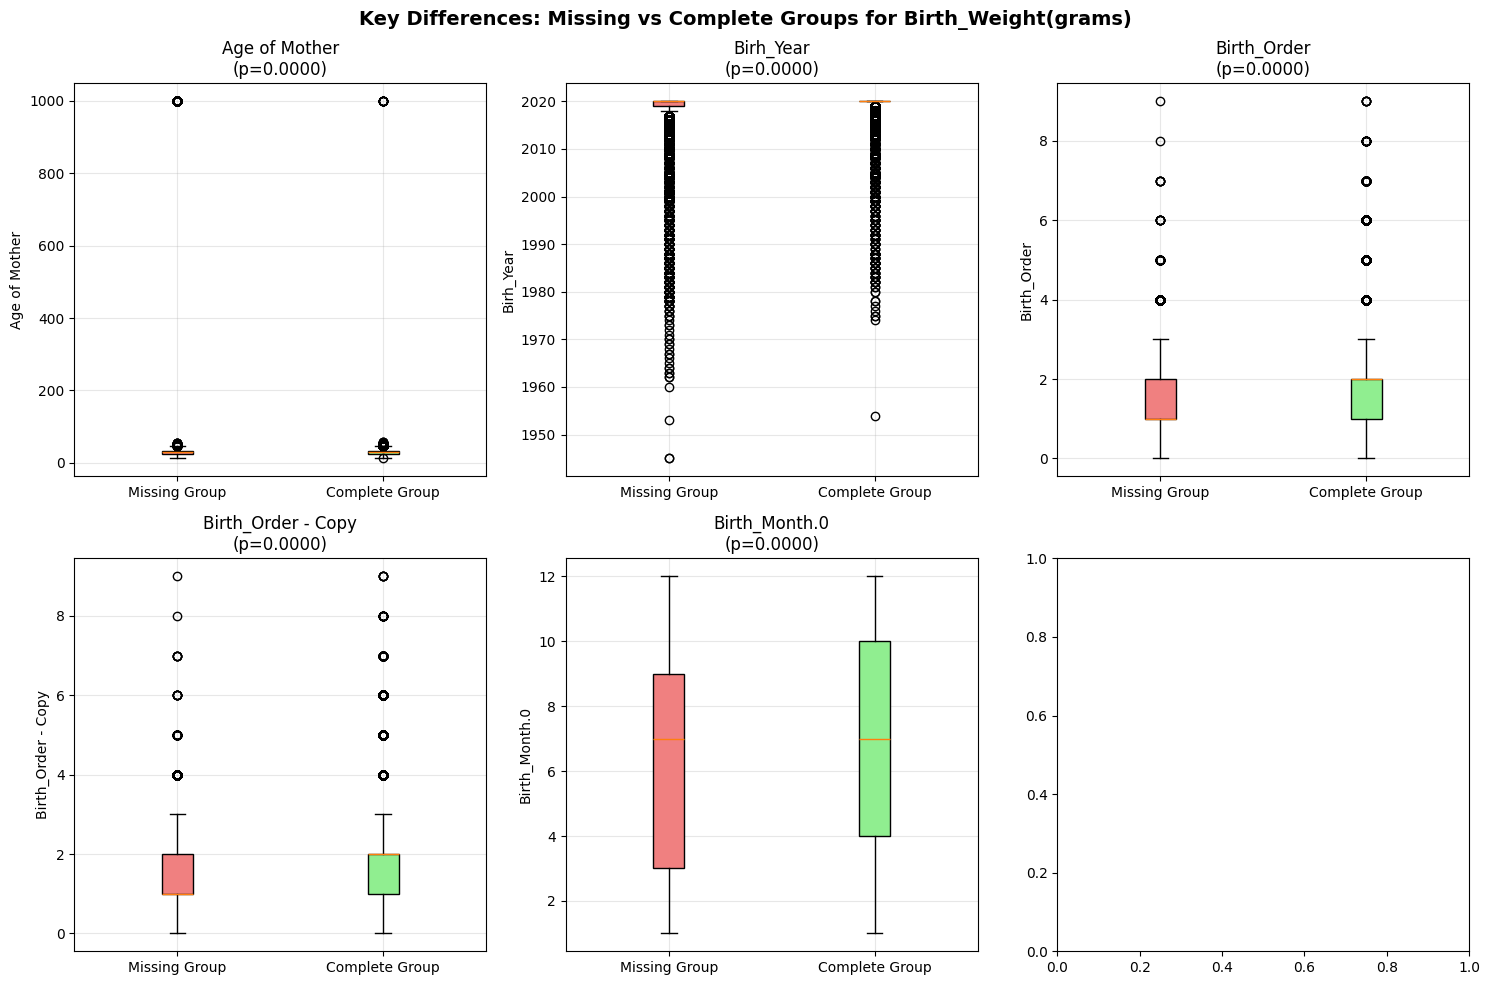

✅ Saved: Birth_Weight(grams)_bias_comparison.png

📋 BIAS ANALYSIS SUMMARY FOR 'Birth_Weight(grams)'

📊 MISSING DATA OVERVIEW:
   • Total records: 301,712
   • Missing Birth_Weight(grams): 33,542 (11.12%)
   • Complete Birth_Weight(grams): 268,170 (88.88%)

🔍 BIAS DETECTION RESULTS:
   • Total comparisons: 17
   • Significant bias detected: 16

📌 VARIABLES WITH SIGNIFICANT BIAS:
   • Registered_Month2.0 (Numeric): p=0.0189
   • Birh_Year (Numeric): p=0.0000
   • Birth_Month.0 (Numeric): p=0.0000
   • Birth_Order (Numeric): p=0.0000
   • Birth_Order - Copy (Numeric): p=0.0000
   • Age of Mother (Numeric): p=0.0000
   • Registered_Month (Categorical): p=0.0000
   • Registered_District (Categorical): p=0.0000
   • Birth_Month (Categorical): p=0.0000
   • Gender (Categorical): p=0.0052

📁 FILES CREATED:
   • missing_analysis_Birth_Weight(grams).xlsx - Complete dataset with missing and complete records
   • Birth_Weight(grams)_bias_comparison.png - Visualization of key differences

✅ ANALYSI

In [13]:



# ============================================
# FOCUS ON BIRTH WEIGHT - CHANGE THIS VARIABLE NAME TO ANALYZE OTHER VARIABLES
# ============================================
TARGET_VARIABLE = 'Birth_Weight(grams)'  # <-- CHANGE THIS to analyze other variables
# ============================================

print(f"\n{'='*70}")
print(f"📊 MISSING DATA BIAS ANALYSIS FOR: '{TARGET_VARIABLE}'")
print(f"{'='*70}")

# Check if variable exists
if TARGET_VARIABLE not in df.columns:
    print(f"❌ ERROR: Variable '{TARGET_VARIABLE}' not found!")
    print(f"Available columns: {list(df.columns)[:20]}...")
    exit()

# Get missing info
missing_count = df[TARGET_VARIABLE].isnull().sum()
missing_pct = (missing_count / len(df)) * 100
complete_count = len(df) - missing_count
complete_pct = 100 - missing_pct

print(f"\n📌 BASIC INFORMATION:")
print(f"   • Total Records: {len(df):,}")
print(f"   • Missing in {TARGET_VARIABLE}: {missing_count:,} ({missing_pct:.2f}%)")
print(f"   • Complete cases: {complete_count:,} ({complete_pct:.2f}%)")

# ============================================
# STEP 1: CREATE SEPARATE DATASETS
# ============================================

print(f"\n📌 STEP 1: CREATING SEPARATE DATASETS")
print("-" * 50)

# Dataset 1: Records with missing birth weight
missing_data = df[df[TARGET_VARIABLE].isnull()]

# Dataset 2: Records with complete birth weight
complete_data = df[df[TARGET_VARIABLE].notnull()]

print(f"   • Missing records: {len(missing_data):,}")
print(f"   • Complete records: {len(complete_data):,}")

# Save to Excel file
filename = f'missing_analysis_{TARGET_VARIABLE}.xlsx'

with pd.ExcelWriter(filename, engine='openpyxl') as writer:
    # Sheet 1: All records with missing birth weight
    missing_data.to_excel(writer, sheet_name=f'Missing_{TARGET_VARIABLE}', index=False)
    
    # Sheet 2: All records with complete birth weight
    complete_data.to_excel(writer, sheet_name=f'Complete_{TARGET_VARIABLE}', index=False)
    
    # Sheet 3: Summary statistics
    summary = pd.DataFrame({
        'Metric': [
            'Variable Name',
            'Total Records',
            f'Missing in {TARGET_VARIABLE}',
            'Missing %',
            f'Complete {TARGET_VARIABLE}',
            'Complete %'
        ],
        'Value': [
            TARGET_VARIABLE,
            f"{len(df):,}",
            f"{missing_count:,}",
            f"{missing_pct:.2f}%",
            f"{complete_count:,}",
            f"{complete_pct:.2f}%"
        ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print(f"✅ Created: {filename}")

# ============================================
# STEP 2: COMPARE MISSING VS COMPLETE GROUPS
# ============================================

print(f"\n📌 STEP 2: BIAS ANALYSIS - COMPARING GROUPS")
print("-" * 70)

bias_results = []

# Compare NUMERIC variables
print(f"\n🔍 Comparing NUMERIC variables between groups:")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for num_col in numeric_cols:
    if num_col != TARGET_VARIABLE:
        # Get means for both groups (ignoring missing in the comparison variable)
        missing_mean = missing_data[num_col].mean()
        complete_mean = complete_data[num_col].mean()
        
        # Only compare if both groups have data
        if not np.isnan(missing_mean) and not np.isnan(complete_mean):
            # Statistical test
            try:
                t_stat, p_value = stats.ttest_ind(
                    missing_data[num_col].dropna(),
                    complete_data[num_col].dropna(),
                    equal_var=False
                )
                
                bias_detected = p_value < 0.05
                
                bias_results.append({
                    'Variable_Type': 'Numeric',
                    'Variable_Name': num_col,
                    'Missing_Group_Mean': f"{missing_mean:.2f}",
                    'Complete_Group_Mean': f"{complete_mean:.2f}",
                    'Difference': f"{missing_mean - complete_mean:.2f}",
                    'Difference_%': f"{((missing_mean - complete_mean) / complete_mean * 100):.1f}%" if complete_mean != 0 else "N/A",
                    'P_Value': f"{p_value:.4f}",
                    'Significant_Bias': 'YES' if bias_detected else 'NO'
                })
                
                if bias_detected:
                    print(f"   ⚠️  {num_col}:")
                    print(f"      Missing group: {missing_mean:.2f} vs Complete: {complete_mean:.2f}")
                    print(f"      Difference: {missing_mean - complete_mean:.2f} (p={p_value:.4f})")
            except:
                pass

# Compare CATEGORICAL variables
print(f"\n🔍 Comparing CATEGORICAL variables between groups:")

cat_cols = df.select_dtypes(include=['object', 'category']).columns

for cat_col in cat_cols:
    if cat_col != TARGET_VARIABLE:
        try:
            # Create contingency table
            missing_indicator = ['Missing' if x else 'Complete' for x in df[TARGET_VARIABLE].isnull()]
            contingency = pd.crosstab(
                pd.Series(missing_indicator, name='Group'),
                df[cat_col]
            )
            
            # Chi-square test
            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
            
            bias_detected = p_value < 0.05
            
            # Get distributions
            missing_dist = missing_data[cat_col].value_counts(normalize=True).head(3)
            complete_dist = complete_data[cat_col].value_counts(normalize=True).head(3)
            
            bias_results.append({
                'Variable_Type': 'Categorical',
                'Variable_Name': cat_col,
                'Missing_Group_Mean': str(dict(missing_dist))[:50],
                'Complete_Group_Mean': str(dict(complete_dist))[:50],
                'Difference': 'N/A',
                'Difference_%': 'N/A',
                'P_Value': f"{p_value:.4f}",
                'Significant_Bias': 'YES' if bias_detected else 'NO'
            })
            
            if bias_detected:
                print(f"   ⚠️  {cat_col}: p={p_value:.4f} - Significant bias detected")
        except:
            pass

# ============================================
# STEP 3: ADD BIAS RESULTS TO EXCEL
# ============================================

print(f"\n📌 STEP 3: ADDING BIAS ANALYSIS TO EXCEL")
print("-" * 50)

# Add bias results to the Excel file
with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
    if bias_results:
        bias_df = pd.DataFrame(bias_results)
        bias_df = bias_df.sort_values('P_Value')
        bias_df.to_excel(writer, sheet_name='Bias_Analysis', index=False)
        print(f"   ✅ Added Bias Analysis sheet with {len(bias_df)} comparisons")

print(f"\n✅ Updated Excel file: {filename}")

# ============================================
# STEP 4: VISUALIZE KEY DIFFERENCES
# ============================================

print(f"\n📌 STEP 4: CREATING VISUALIZATIONS")
print("-" * 50)

# Select top 5 numeric variables with largest differences
numeric_bias = [r for r in bias_results if r['Variable_Type'] == 'Numeric' and r['Significant_Bias'] == 'YES']
numeric_bias = sorted(numeric_bias, key=lambda x: abs(float(x['Difference'])), reverse=True)[:5]

if numeric_bias:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, bias in enumerate(numeric_bias):
        if i < 5:
            var_name = bias['Variable_Name']
            
            # Create boxplot comparison
            data_to_plot = [
                missing_data[var_name].dropna(),
                complete_data[var_name].dropna()
            ]
            
            bp = axes[i].boxplot(data_to_plot, patch_artist=True, labels=['Missing Group', 'Complete Group'])
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            axes[i].set_title(f'{var_name}\n(p={bias["P_Value"]})')
            axes[i].set_ylabel(var_name)
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplot
    if len(numeric_bias) < 5:
        axes[5].axis('off')
    
    plt.suptitle(f'Key Differences: Missing vs Complete Groups for {TARGET_VARIABLE}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{TARGET_VARIABLE}_bias_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {TARGET_VARIABLE}_bias_comparison.png")

# ============================================
# STEP 5: SUMMARY REPORT
# ============================================

print(f"\n{'='*70}")
print(f"📋 BIAS ANALYSIS SUMMARY FOR '{TARGET_VARIABLE}'")
print(f"{'='*70}")

print(f"\n📊 MISSING DATA OVERVIEW:")
print(f"   • Total records: {len(df):,}")
print(f"   • Missing {TARGET_VARIABLE}: {missing_count:,} ({missing_pct:.2f}%)")
print(f"   • Complete {TARGET_VARIABLE}: {complete_count:,} ({complete_pct:.2f}%)")

print(f"\n🔍 BIAS DETECTION RESULTS:")
if bias_results:
    significant_bias = [r for r in bias_results if r['Significant_Bias'] == 'YES']
    print(f"   • Total comparisons: {len(bias_results)}")
    print(f"   • Significant bias detected: {len(significant_bias)}")
    
    if significant_bias:
        print(f"\n📌 VARIABLES WITH SIGNIFICANT BIAS:")
        for bias in significant_bias[:10]:  # Show top 10
            print(f"   • {bias['Variable_Name']} ({bias['Variable_Type']}): p={bias['P_Value']}")
else:
    print(f"   • No bias comparisons could be performed")

print(f"\n📁 FILES CREATED:")
print(f"   • {filename} - Complete dataset with missing and complete records")
if numeric_bias:
    print(f"   • {TARGET_VARIABLE}_bias_comparison.png - Visualization of key differences")

print(f"\n{'='*70}")
print(f"✅ ANALYSIS COMPLETE")
print(f"{'='*70}")  # <-- FIXED: removed the '=' inside the f-string

# ============================================
# STEP 6: QUICK RECOMMENDATIONS
# ============================================

print(f"\n📋 RECOMMENDATIONS FOR '{TARGET_VARIABLE}':")
print("-" * 50)

if missing_pct < 1:
    print(f"✅ Very few missing ({missing_pct:.1f}%) - Can drop rows or use simple imputation")
elif missing_pct < 5:
    print(f"🟡 Some missing ({missing_pct:.1f}%) - Imputation recommended")
    if significant_bias:
        print(f"   ⚠️  But bias detected - consider keeping missing indicator")
elif missing_pct < 20:
    print(f"🟠 Moderate missing ({missing_pct:.1f}%) - Careful handling needed")
    if significant_bias:
        print(f"   ⚠️  Bias detected - missingness may be informative")
    else:
        print(f"   ✅ No significant bias - imputation may be safe")
elif missing_pct < 50:
    print(f"🔴 High missing ({missing_pct:.1f}%) - Consider dropping or creating missing category")
else:
    print(f"⚫ Very high missing ({missing_pct:.1f}%) - Likely drop this variable")


🔍 ANALYZING PATTERNS WITHIN MISSING BIRTH WEIGHT RECORDS

📊 ANALYZING 33,542 RECORDS WITH MISSING BIRTH WEIGHT

📌 STEP 1: CLUSTERING ANALYSIS - FINDING NATURAL GROUPINGS
----------------------------------------------------------------------
   Found 8 numeric columns and 10 categorical columns
   Using 8 numeric and 10 categorical features

📌 STEP 2: PREPARING DATA FOR CLUSTERING
----------------------------------------------------------------------
   Processing 8 numeric features...
   Found 7 numeric features with data
   ✅ Added 7 scaled numeric features

   Processing 10 categorical features...
      • Encoded Registered_Month (12 categories)
      • Encoded Registered_District (25 categories)
      • Encoded Birth_Month (12 categories)
      • Encoded Gender (3 categories)
      • Encoded Hospital or Not (2 categories)
      • Encoded Multiple_Birth_Status (5 categories)
      • Encoded Marital_Status (3 categories)
      • Encoded District_of_Mother (27 categories)
      • Enco

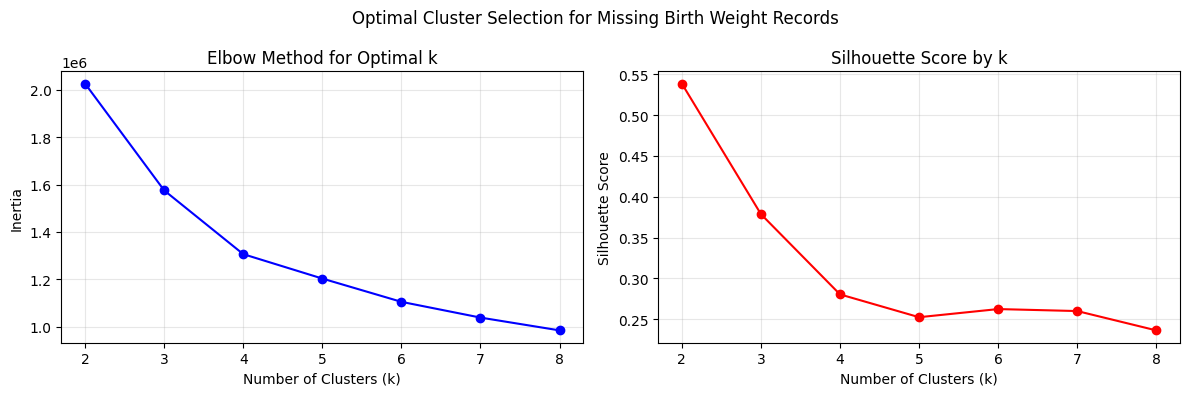


✅ Optimal number of clusters: 2

📌 STEP 4: ANALYZING CLUSTER CHARACTERISTICS
----------------------------------------------------------------------

📍 CLUSTER 0: 26218 records (78.2%)
   Key distinguishing characteristics:
      • Registered_Month: most common is 'September' (12.1%)
      • Registered_District: most common is 'Batticaloa' (29.2%)
      • Birth_Month: most common is 'August' (10.6%)
      • Gender: most common is 'Male' (50.3%)
      • Hospital or Not: most common is 'Hospital' (99.2%)

📍 CLUSTER 1: 7324 records (21.8%)
   Key distinguishing characteristics:
      • Registered_Month: most common is 'August' (20.4%)
      • Registered_District: most common is 'Kurunagala' (16.0%)
      • Birth_Month: most common is 'July' (12.1%)
      • Gender: most common is 'Male' (51.3%)
      • Hospital or Not: most common is 'Hospital' (97.0%)

📌 STEP 5: VISUALIZING CLUSTERS
----------------------------------------------------------------------


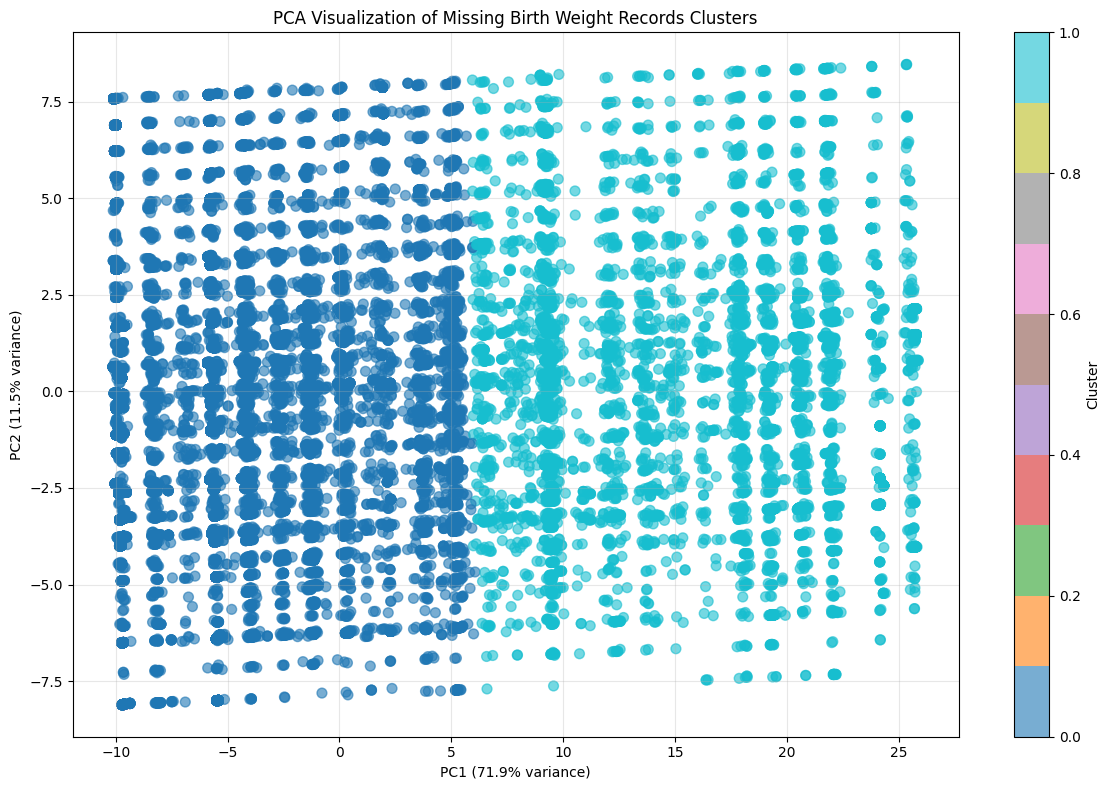


📌 STEP 6: CREATING SUMMARY REPORT
----------------------------------------------------------------------
✅ Saved: missing_birthweight_clusters.xlsx with cluster assignments

📋 PATTERN ANALYSIS SUMMARY

🔍 KEY FINDINGS:
   • 33,542 records analyzed for patterns
   • Identified 2 distinct clusters/patterns

📊 CLUSTER DISTRIBUTION:
   • Cluster 0: 26218 records (78.2%)
   • Cluster 1: 7324 records (21.8%)

🎯 INTERPRETATION FOR MANUAL DATA ENTRY:
--------------------------------------------------
✅ MULTIPLE PATTERNS DETECTED
   This suggests missing birth weight follows specific patterns
   Different groups of records show different characteristics

   🔍 SUGGESTION: The patterns are clear and manageable
      Review each cluster's characteristics to identify
      the specific reason for each pattern

📁 FILES GENERATED:
   • missing_data_clustering_elbow.png - Cluster selection plot
   • missing_data_clusters_pca.png - Cluster visualization
   • missing_birthweight_clusters.xlsx - Data wit

In [17]:
# ============================================
# ANALYSIS OF SIMILARITIES WITHIN MISSING BIRTH WEIGHT RECORDS
# ============================================

print(f"\n{'='*70}")
print(f"🔍 ANALYZING PATTERNS WITHIN MISSING BIRTH WEIGHT RECORDS")
print(f"{'='*70}")

# Load the missing data we created earlier
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()

print(f"\n📊 ANALYZING {len(missing_data):,} RECORDS WITH MISSING BIRTH WEIGHT")

# ============================================
# 1. CLUSTERING ANALYSIS TO FIND NATURAL GROUPINGS
# ============================================

print(f"\n📌 STEP 1: CLUSTERING ANALYSIS - FINDING NATURAL GROUPINGS")
print("-" * 70)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Prepare data for clustering
cluster_data = missing_data.copy()

# Separate numeric and categorical columns
numeric_cols = cluster_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = cluster_data.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"   Found {len(numeric_cols)} numeric columns and {len(categorical_cols)} categorical columns")

# Select features for clustering (excluding identifiers)
exclude_patterns = ['ID', 'id', 'Name', 'name', 'Patient', 'Date', 'date', 'Time', 'time']
numeric_features = [col for col in numeric_cols if not any(pattern in col for pattern in exclude_patterns)]
categorical_features = [col for col in categorical_cols if not any(pattern in col for pattern in exclude_patterns)]

print(f"   Using {len(numeric_features)} numeric and {len(categorical_features)} categorical features")

# ============================================
# 2. PREPARE DATA FOR CLUSTERING
# ============================================

print(f"\n📌 STEP 2: PREPARING DATA FOR CLUSTERING")
print("-" * 70)

encoded_data = pd.DataFrame(index=cluster_data.index)

# Handle numeric columns carefully
if numeric_features:
    print(f"   Processing {len(numeric_features)} numeric features...")
    
    # First, check which numeric columns actually have data
    valid_numeric_features = []
    for col in numeric_features:
        if cluster_data[col].notna().sum() > 0:  # Column has at least one non-null value
            valid_numeric_features.append(col)
    
    print(f"   Found {len(valid_numeric_features)} numeric features with data")
    
    if valid_numeric_features:
        # Create numeric data array
        numeric_data_list = []
        valid_columns = []
        
        for col in valid_numeric_features:
            col_data = cluster_data[col].fillna(cluster_data[col].median()).values.reshape(-1, 1)
            numeric_data_list.append(col_data)
            valid_columns.append(col)
        
        if numeric_data_list:
            # Combine all numeric columns
            numeric_array = np.hstack(numeric_data_list)
            
            # Scale numeric data
            scaler = StandardScaler()
            scaled_numeric = scaler.fit_transform(numeric_array)
            
            # Add to encoded data with original column names
            for i, col in enumerate(valid_columns):
                encoded_data[col] = scaled_numeric[:, i]
            
            print(f"   ✅ Added {len(valid_columns)} scaled numeric features")
else:
    valid_numeric_features = []
    print("   No numeric features found")

# Handle categorical columns
if categorical_features:
    print(f"\n   Processing {len(categorical_features)} categorical features...")
    
    valid_categorical_features = []
    for col in categorical_features:
        if cluster_data[col].nunique() > 1:  # Column has variation
            # Fill missing with 'MISSING' and encode
            non_null = cluster_data[col].fillna('MISSING').astype(str)
            
            # Only use if not too many unique values
            if non_null.nunique() <= 50:  # Limit to reasonable number of categories
                le = LabelEncoder()
                encoded_data[f'{col}'] = le.fit_transform(non_null)
                valid_categorical_features.append(col)
                print(f"      • Encoded {col} ({non_null.nunique()} categories)")
            else:
                print(f"      • Skipped {col} (too many categories: {non_null.nunique()})")
    
    print(f"   ✅ Added {len(valid_categorical_features)} encoded categorical features")
else:
    valid_categorical_features = []
    print("   No categorical features found")

# Check if we have data for clustering
if len(encoded_data.columns) == 0:
    print("❌ ERROR: No suitable features for clustering!")
    print("   Trying alternative approach with basic features...")
    
    # Alternative: use any numeric columns that exist
    basic_features = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] 
                     and col != TARGET_VARIABLE
                     and 'ID' not in col and 'id' not in col][:5]
    
    if basic_features:
        for col in basic_features:
            if col in missing_data.columns:
                encoded_data[col] = missing_data[col].fillna(missing_data[col].median())
        
        # Scale the basic features
        scaler = StandardScaler()
        scaled_basic = scaler.fit_transform(encoded_data)
        encoded_data = pd.DataFrame(scaled_basic, columns=encoded_data.columns, index=encoded_data.index)
        print(f"   ✅ Using {len(basic_features)} basic features for clustering")
    else:
        print("❌ No features available for clustering")
        exit()

print(f"\n📊 Final feature set: {encoded_data.shape[1]} features for {len(encoded_data)} records")
print(f"   Features: {', '.join(encoded_data.columns[:10])}")

# Remove any rows with NaN or infinite values
encoded_data = encoded_data.replace([np.inf, -np.inf], np.nan)
encoded_data = encoded_data.dropna()
print(f"   After cleaning: {len(encoded_data)} records available for clustering")

if len(encoded_data) < 10:
    print("❌ Too few records for clustering after cleaning")
    exit()

# ============================================
# 3. PERFORM CLUSTERING
# ============================================

print(f"\n📌 STEP 3: PERFORMING CLUSTERING ANALYSIS")
print("-" * 70)

# Find optimal number of clusters
max_clusters = min(8, len(encoded_data) // 20 + 2)
if max_clusters < 2:
    max_clusters = 2

K_range = range(2, max_clusters + 1)
inertias = []
silhouette_scores = []

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(encoded_data)
    inertias.append(kmeans.inertia_)
    if len(set(labels)) > 1:
        try:
            score = silhouette_score(encoded_data, labels)
            silhouette_scores.append(score)
        except:
            silhouette_scores.append(-1)
    else:
        silhouette_scores.append(-1)

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimal Cluster Selection for Missing Birth Weight Records')
plt.tight_layout()
plt.savefig('missing_data_clustering_elbow.png', dpi=300, bbox_inches='tight')
plt.show()

# Choose optimal k (best silhouette score)
if max(silhouette_scores) > 0:
    optimal_k = K_range[np.argmax(silhouette_scores)]
else:
    optimal_k = 2  # Default to 2 clusters if silhouette scores are bad

print(f"\n✅ Optimal number of clusters: {optimal_k}")

# Perform final clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
missing_data_aligned = missing_data.loc[encoded_data.index]  # Align indices
missing_data_aligned['Cluster'] = kmeans.fit_predict(encoded_data)

# ============================================
# 4. ANALYZE EACH CLUSTER'S CHARACTERISTICS
# ============================================

print(f"\n📌 STEP 4: ANALYZING CLUSTER CHARACTERISTICS")
print("-" * 70)

cluster_summary = pd.DataFrame()

for cluster in range(optimal_k):
    cluster_records = missing_data_aligned[missing_data_aligned['Cluster'] == cluster]
    print(f"\n📍 CLUSTER {cluster}: {len(cluster_records)} records ({len(cluster_records)/len(missing_data_aligned)*100:.1f}%)")
    
    print(f"   Key distinguishing characteristics:")
    char_count = 0
    
    # Analyze numeric features
    for col in valid_numeric_features[:5]:  # Limit to top 5 numeric
        if col in cluster_records.columns:
            cluster_mean = cluster_records[col].mean()
            overall_mean = missing_data_aligned[col].mean()
            cluster_std = cluster_records[col].std()
            
            if pd.notna(cluster_mean) and pd.notna(overall_mean) and overall_mean != 0:
                diff_pct = ((cluster_mean - overall_mean) / abs(overall_mean)) * 100
                if abs(diff_pct) > 20:  # Show if >20% different
                    print(f"      • {col}: {cluster_mean:.2f} ± {cluster_std:.2f} vs overall {overall_mean:.2f} ({diff_pct:+.1f}%)")
                    char_count += 1
    
    # Analyze categorical features
    for col in valid_categorical_features[:5]:  # Limit to top 5 categorical
        if col in cluster_records.columns:
            # Get top category in this cluster
            cluster_top = cluster_records[col].value_counts()
            if len(cluster_top) > 0:
                cluster_top_cat = cluster_top.index[0]
                cluster_top_pct = (cluster_top.iloc[0] / len(cluster_records)) * 100
                
                # Get original value (decode if needed)
                if isinstance(cluster_top_cat, (int, np.integer)):
                    # Try to get original category if we encoded it
                    original_val = 'Unknown'
                else:
                    original_val = cluster_top_cat
                
                print(f"      • {col}: most common is '{original_val}' ({cluster_top_pct:.1f}%)")
                char_count += 1
    
    if char_count == 0:
        print(f"      • No strongly distinguishing characteristics found")

# ============================================
# 5. VISUALIZE CLUSTERS
# ============================================

print(f"\n📌 STEP 5: VISUALIZING CLUSTERS")
print("-" * 70)

# PCA for visualization
n_components = min(2, encoded_data.shape[1])
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(encoded_data)

# Create cluster visualization
plt.figure(figsize=(12, 8))

if pca_result.shape[1] >= 2:
    # Scatter plot with clusters
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                         c=missing_data_aligned['Cluster'], cmap='tab10', 
                         alpha=0.6, s=50)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
else:
    # If only 1 component, plot against index
    scatter = plt.scatter(range(len(pca_result)), pca_result[:, 0], 
                         c=missing_data_aligned['Cluster'], cmap='tab10', 
                         alpha=0.6, s=50)
    plt.xlabel('Record Index')
    plt.ylabel('PC1')

plt.title('PCA Visualization of Missing Birth Weight Records Clusters')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('missing_data_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. CREATE SUMMARY REPORT
# ============================================

print(f"\n📌 STEP 6: CREATING SUMMARY REPORT")
print("-" * 70)

# Save cluster assignments
output_file = 'missing_birthweight_clusters.xlsx'
missing_data_aligned.to_excel(output_file, index=False)
print(f"✅ Saved: {output_file} with cluster assignments")

# Create simple text summary
print(f"\n{'='*70}")
print(f"📋 PATTERN ANALYSIS SUMMARY")
print(f"{'='*70}")

print(f"\n🔍 KEY FINDINGS:")
print(f"   • {len(missing_data_aligned):,} records analyzed for patterns")
print(f"   • Identified {optimal_k} distinct clusters/patterns")

print(f"\n📊 CLUSTER DISTRIBUTION:")
for cluster in range(optimal_k):
    size = len(missing_data_aligned[missing_data_aligned['Cluster'] == cluster])
    pct = (size/len(missing_data_aligned))*100
    print(f"   • Cluster {cluster}: {size} records ({pct:.1f}%)")

print(f"\n🎯 INTERPRETATION FOR MANUAL DATA ENTRY:")
print("-" * 50)

if optimal_k > 1:
    print(f"✅ MULTIPLE PATTERNS DETECTED")
    print(f"   This suggests missing birth weight follows specific patterns")
    print(f"   Different groups of records show different characteristics")
    
    if optimal_k <= 3:
        print(f"\n   🔍 SUGGESTION: The patterns are clear and manageable")
        print(f"      Review each cluster's characteristics to identify")
        print(f"      the specific reason for each pattern")
    else:
        print(f"\n   🔍 SUGGESTION: Multiple patterns detected - consider if")
        print(f"      they correspond to different time periods, locations,")
        print(f"      or data entry personnel")
else:
    print(f"⚠️ SINGLE PATTERN DETECTED")
    print(f"   Missingness appears uniform across records")
    print(f"   May be random or consistently missing for all cases")

print(f"\n📁 FILES GENERATED:")
print(f"   • missing_data_clustering_elbow.png - Cluster selection plot")
print(f"   • missing_data_clusters_pca.png - Cluster visualization")
print(f"   • missing_birthweight_clusters.xlsx - Data with cluster assignments")

print(f"\n{'='*70}")
print(f"✅ PATTERN ANALYSIS COMPLETE")
print(f"{'='*70}")

# ============================================
# 7. NEXT STEPS
# ============================================

print(f"\n📋 RECOMMENDED NEXT STEPS:")
print("-" * 50)

print(f"\n1. REVIEW THE CLUSTERS:")
print(f"   • Open 'missing_birthweight_clusters.xlsx'")
print(f"   • Look at each cluster's records - what do they have in common?")

print(f"\n2. CHECK FOR TEMPORAL PATTERNS:")
print(f"   • If you have date fields, check if clusters correspond to specific time periods")

print(f"\n3. VERIFY WITH DATA ENTRY STAFF:")
print(f"   • Share the patterns with people who entered the data")
print(f"   • Ask if they recognize these groupings")

print(f"\n4. DECISION FOR ANALYSIS:")
if optimal_k > 1:
    print(f"   • Since clear patterns exist, consider keeping 'missing' as a separate category")
    print(f"   • Or analyze each cluster separately if they represent meaningful groups")
else:
    print(f"   • Since no strong patterns, simple imputation may be acceptable")

print(f"\n{'='*70}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT RECORDS

📌 DATASET OVERVIEW:
   • Total records with missing birth weight: 33,542
   • Total records with complete birth weight: 268,170

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

📌 PART 2: MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS

🔍 CORRELATION MATRIX (Numeric Variables):

   Strong Correlations Found:
   • Birth_Order & Birth_Order - Copy: 1.000 (Very Strong)

🔍 CATEGORICAL ASSOCIATIONS:
   • Registered_Month & Registered_District: p=0.0000, Cramer's V=0.212
   • Registered_Month & Birth_Month: p=0.0000, Cramer's V=0.393
   • Registered_Month & Hospital or Not: p=0.0000, Cramer's V=0.037
   • Registered_District & Birth_Month: p=0.0000, Cramer's V=0.136
   • Registered_District & Gender: p=0.0000, Cramer's V=0.038
   • Registered_District & Hospital or Not: p=0.0000, Cramer's V=0.232

📌 PART 3: MISSINGNESS PATTERN ANALYSIS

🔍 VARIABLES THAT TEND TO BE MISSING TOGETHER:
   • Birth_Order

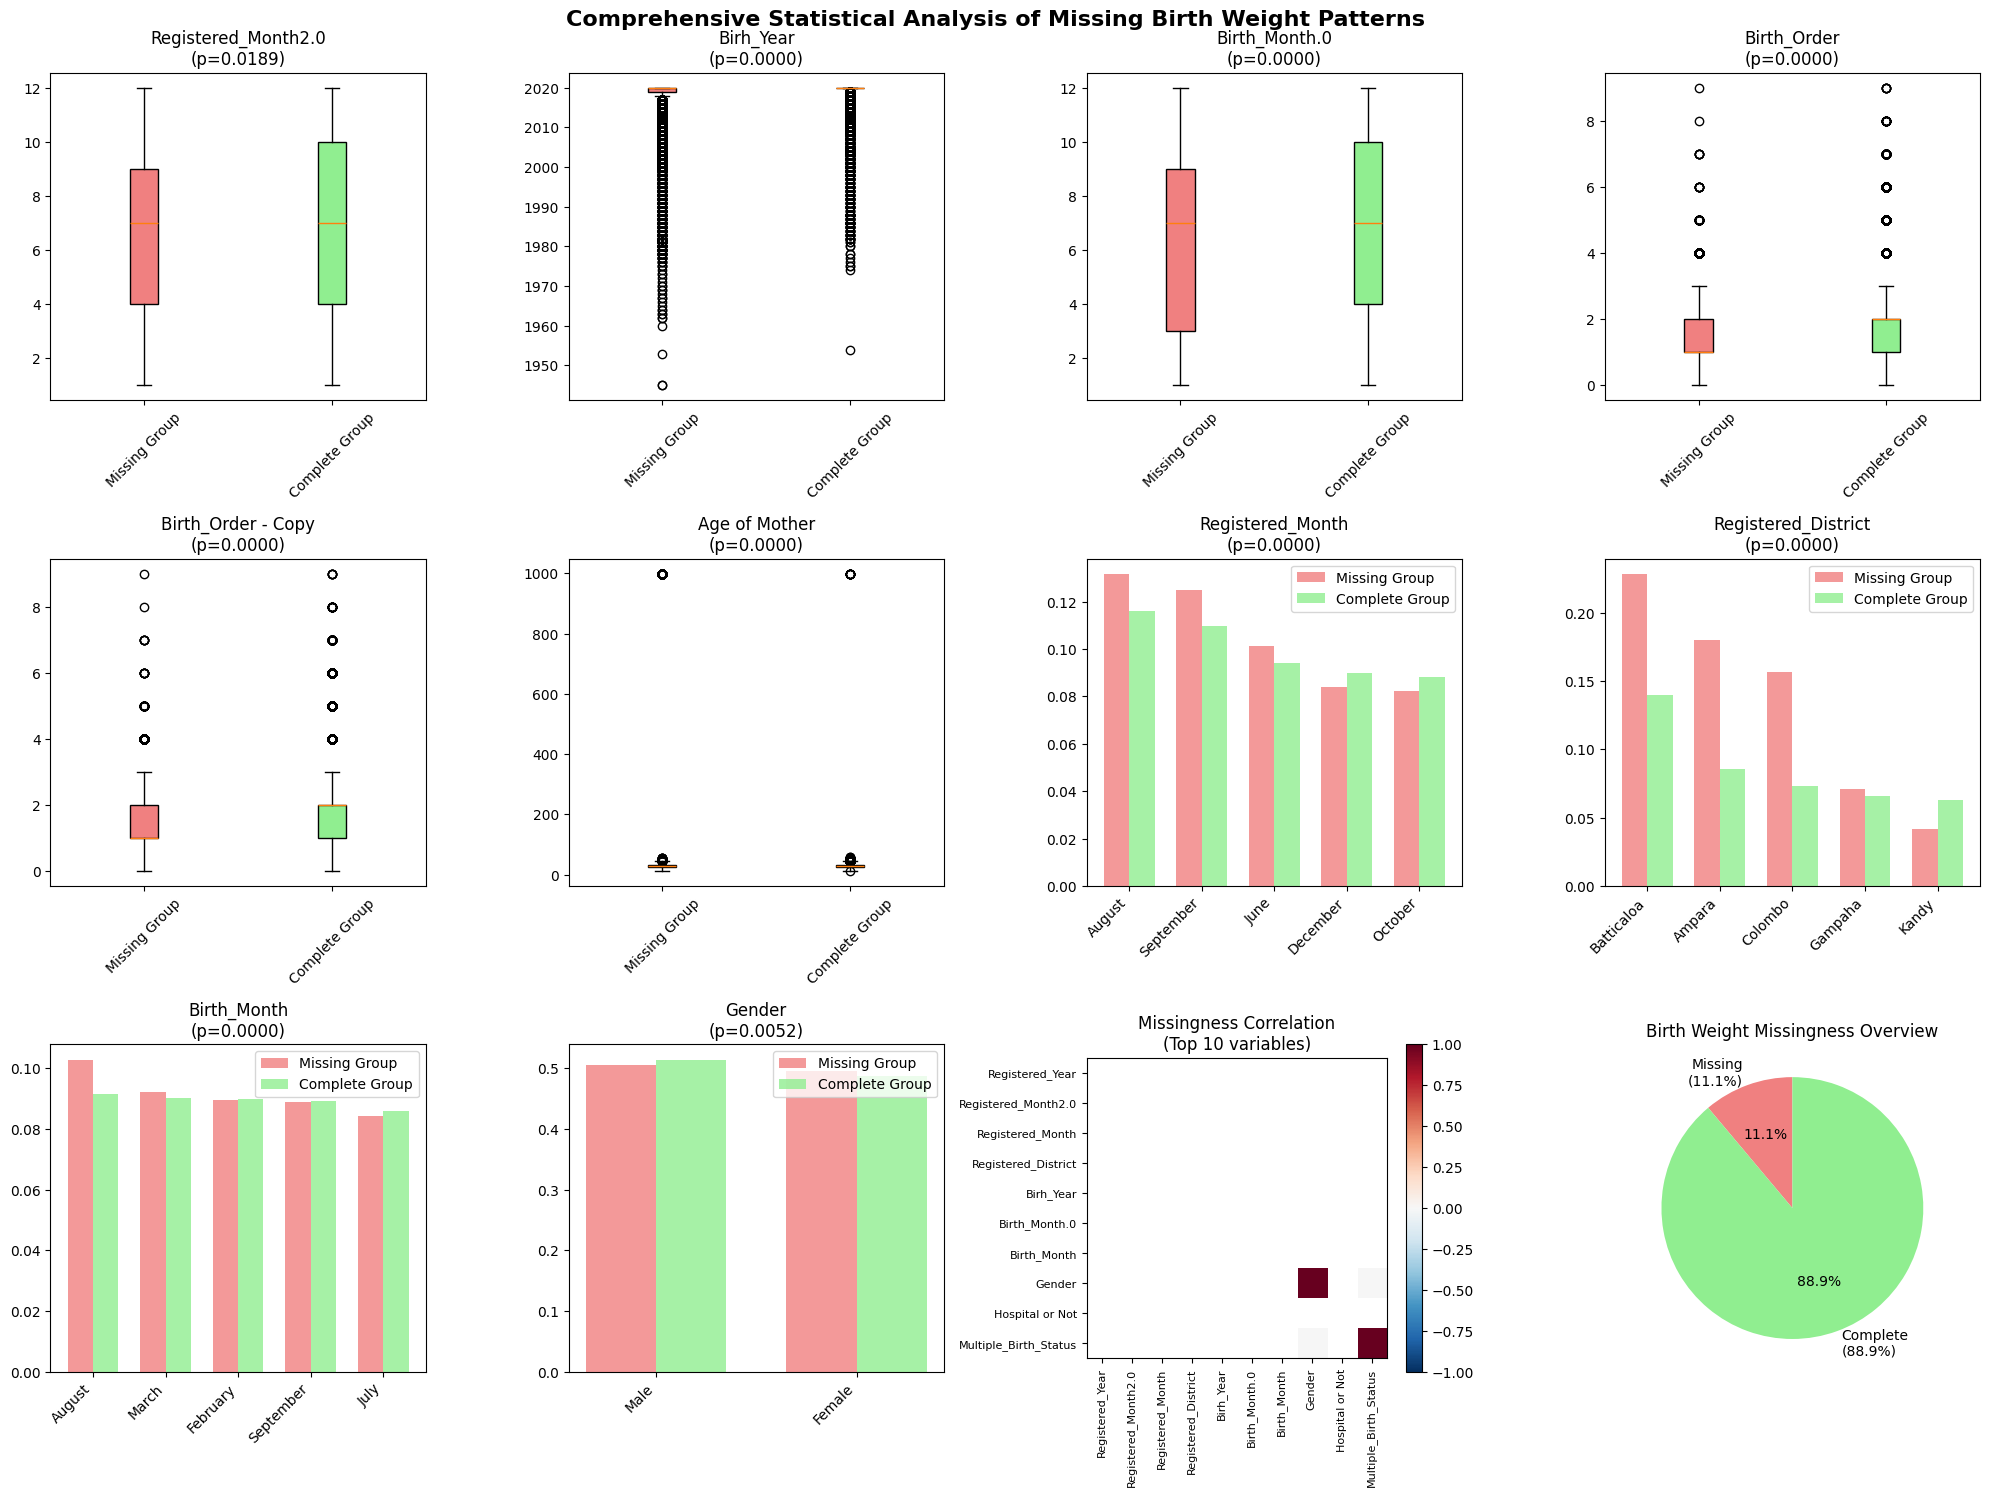


📋 COMPREHENSIVE STATISTICAL SUMMARY

📊 OVERALL STATISTICS:
   • Total missing birth weight records: 33,542 (11.1% of total)
   • Number of variables analyzed: 18
   • Numeric variables: 8
   • Categorical variables: 10

🔍 VARIABLES WITH SIGNIFICANT DIFFERENCES (p < 0.05):
   • Registered_Month2.0: Mean=6.80 vs Complete Mean (diff: 0.05, p=0.0189)
   • Registered_Month: Most common='August' (13.2%), p=0.0000
   • Registered_District: Most common='Batticaloa' (22.8%), p=0.0000
   • Birh_Year: Mean=2018.30 vs Complete Mean (diff: -1.51, p=0.0000)
   • Birth_Month.0: Mean=6.42 vs Complete Mean (diff: -0.18, p=0.0000)
   • Birth_Month: Most common='August' (10.3%), p=0.0000
   • Gender: Most common='Male' (50.5%), p=0.0052
   • Hospital or Not: Most common='Hospital' (98.7%), p=0.0000
   • Multiple_Birth_Status: Most common='missing' (99.4%), p=0.0000
   • Birth_Order: Mean=1.37 vs Complete Mean (diff: -0.50, p=0.0000)
   • Birth_Order - Copy: Mean=1.37 vs Complete Mean (diff: -0.50, p=0.0

In [30]:
# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT PATTERNS
# ============================================

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT RECORDS")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing birth weight: {len(missing_data):,}")
print(f"   • Total records with complete birth weight: {len(complete_data):,}")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []

# Analyze each column in the missing data
for col in missing_data.columns:
    if col == TARGET_VARIABLE:
        continue
        
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Statistics based on data type
    if missing_data[col].dtype in ['int64', 'float64']:
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            # Central tendency
            col_stats.update({
                'Mean': valid_data.mean(),
                'Median': valid_data.median(),
                'Mode': valid_data.mode().iloc[0] if len(valid_data.mode()) > 0 else np.nan,
                'Std_Dev': valid_data.std(),
                'Variance': valid_data.var(),
                'Min': valid_data.min(),
                'Max': valid_data.max(),
                'Range': valid_data.max() - valid_data.min(),
                'Q1': valid_data.quantile(0.25),
                'Q3': valid_data.quantile(0.75),
                'IQR': valid_data.quantile(0.75) - valid_data.quantile(0.25),
                'Skewness': valid_data.skew(),
                'Kurtosis': valid_data.kurtosis(),
            })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                from scipy import stats
                t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                col_stats['T_Test_P_Value'] = p_value
                col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                col_stats['Effect_Size'] = (valid_data.mean() - complete_valid_data.mean()) / complete_valid_data.std() if complete_valid_data.std() > 0 else 0
                col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                col_stats['Mean_Difference_%'] = ((valid_data.mean() - complete_valid_data.mean()) / complete_valid_data.mean()) * 100 if complete_valid_data.mean() != 0 else np.nan
            else:
                col_stats['T_Test_P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Effect_Size'] = np.nan
                col_stats['Mean_Difference'] = np.nan
                col_stats['Mean_Difference_%'] = np.nan
        else:
            # No valid data in missing group
            col_stats.update({
                'Mean': np.nan, 'Median': np.nan, 'Mode': np.nan, 'Std_Dev': np.nan,
                'Variance': np.nan, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
                'Q1': np.nan, 'Q3': np.nan, 'IQR': np.nan, 'Skewness': np.nan, 'Kurtosis': np.nan,
                'T_Test_P_Value': np.nan, 'Significant_Difference': 'N/A', 'Effect_Size': np.nan,
                'Mean_Difference': np.nan, 'Mean_Difference_%': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': top_categories.index[0] if len(top_categories) > 0 else np.nan,
                'Most_Common_Count': top_categories.iloc[0] if len(top_categories) > 0 else 0,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': top_categories.index[1] if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': top_categories.index[2] if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
                'Entropy': stats.entropy(value_counts.values) if len(value_counts) > 1 else 0,
            })
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    # Create contingency table
                    missing_cats = valid_data.value_counts()
                    complete_cats = complete_valid.value_counts()
                    
                    # Align categories
                    all_cats = set(missing_cats.index) | set(complete_cats.index)
                    missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                    complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                    
                    # Chi-square test
                    contingency = np.array([missing_counts, complete_counts])
                    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                    
                    col_stats['Chi_Square_P_Value'] = p_value
                    col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                    col_stats['Cramers_V'] = np.sqrt(chi2 / (len(valid_data) + len(complete_valid)))
                else:
                    col_stats['Chi_Square_P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
                    col_stats['Cramers_V'] = np.nan
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_Count': 0, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'Entropy': 0, 'Chi_Square_P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Cramers_V': np.nan
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# ============================================
# 2. MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS")
print(f"{'='*80}")

# Correlation matrix for numeric variables
numeric_vars = missing_data.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_vars) > 1:
    print(f"\n🔍 CORRELATION MATRIX (Numeric Variables):")
    
    # Calculate correlations
    corr_matrix = missing_data[numeric_vars].corr()
    
    # Find strong correlations
    strong_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.5:  # Strong correlation threshold
                strong_corrs.append({
                    'Variable_1': corr_matrix.columns[i],
                    'Variable_2': corr_matrix.columns[j],
                    'Correlation': corr_value,
                    'Strength': 'Very Strong' if abs(corr_value) > 0.8 else 'Strong'
                })
    
    if strong_corrs:
        print("\n   Strong Correlations Found:")
        for corr in strong_corrs:
            print(f"   • {corr['Variable_1']} & {corr['Variable_2']}: {corr['Correlation']:.3f} ({corr['Strength']})")
    else:
        print("\n   No strong correlations found between numeric variables")

# Association for categorical variables
categorical_vars = missing_data.select_dtypes(include=['object', 'category']).columns
if len(categorical_vars) > 1:
    print(f"\n🔍 CATEGORICAL ASSOCIATIONS:")
    
    from scipy.stats import chi2_contingency
    
    for i in range(min(5, len(categorical_vars))):
        for j in range(i+1, min(5, len(categorical_vars))):
            var1, var2 = categorical_vars[i], categorical_vars[j]
            
            # Create contingency table
            contingency = pd.crosstab(missing_data[var1].fillna('MISSING'), 
                                     missing_data[var2].fillna('MISSING'))
            
            if contingency.size > 0:
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                if p_value < 0.05:
                    cramer_v = np.sqrt(chi2 / (len(missing_data) * (min(contingency.shape) - 1)))
                    print(f"   • {var1} & {var2}: p={p_value:.4f}, Cramer's V={cramer_v:.3f}")

# ============================================
# 3. MISSINGNESS PATTERN ANALYSIS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: MISSINGNESS PATTERN ANALYSIS")
print(f"{'='*80}")

# Create missingness matrix
missing_matrix = missing_data.isnull()

# Calculate missingness correlation
missing_corr = missing_matrix.corr()

print(f"\n🔍 VARIABLES THAT TEND TO BE MISSING TOGETHER:")
high_missing_corr = []
for i in range(len(missing_corr.columns)):
    for j in range(i+1, len(missing_corr.columns)):
        if abs(missing_corr.iloc[i, j]) > 0.3:
            high_missing_corr.append({
                'Var1': missing_corr.columns[i],
                'Var2': missing_corr.columns[j],
                'Correlation': missing_corr.iloc[i, j]
            })

if high_missing_corr:
    for item in sorted(high_missing_corr, key=lambda x: abs(x['Correlation']), reverse=True)[:10]:
        print(f"   • {item['Var1']} & {item['Var2']}: {item['Correlation']:.3f}")
else:
    print("   No strong missingness correlations found")

# ============================================
# 4. CREATE COMPREHENSIVE EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING COMPREHENSIVE STATISTICAL REPORT")
print(f"{'='*80}")

output_file = 'missing_birthweight_comprehensive_stats.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    
    # Sheet 1: Variable-level Statistics
    stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
    
    # Sheet 2: Summary Statistics
    summary_stats = pd.DataFrame({
        'Metric': ['Total Missing Records', 'Total Variables', 'Numeric Variables', 'Categorical Variables'],
        'Value': [
            len(missing_data),
            len(missing_data.columns),
            len(numeric_vars),
            len(categorical_vars)
        ]
    })
    summary_stats.to_excel(writer, sheet_name='Summary', index=False)
    
    # Sheet 3: Variables with Significant Differences
    sig_diff = stats_df[stats_df['Significant_Difference'] == 'YES']
    if not sig_diff.empty:
        sig_diff.to_excel(writer, sheet_name='Significant_Differences', index=False)
    
    # Sheet 4: Missingness Correlation
    missing_corr.to_excel(writer, sheet_name='Missing_Correlations')
    
    # Sheet 5: Numeric Correlations
    if len(numeric_vars) > 1:
        corr_matrix.to_excel(writer, sheet_name='Numeric_Correlations')
    
    # Sheet 6: Frequency Tables for Key Categorical Variables
    for cat_var in categorical_vars[:5]:  # Limit to first 5
        if missing_data[cat_var].notna().sum() > 0:
            freq_table = pd.DataFrame({
                'Category': missing_data[cat_var].value_counts().index,
                'Count': missing_data[cat_var].value_counts().values,
                'Percentage': (missing_data[cat_var].value_counts().values / len(missing_data)) * 100
            })
            sheet_name = f'Freq_{cat_var[:20]}'  # Limit sheet name length
            freq_table.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"✅ Created comprehensive statistical report: {output_file}")

# ============================================
# 5. VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 5: CREATING STATISTICAL VISUALIZATIONS")
print(f"{'='*80}")

# Create a multi-panel figure
fig = plt.figure(figsize=(20, 15))

# 1. Box plots for numeric variables with significant differences
sig_numeric = stats_df[(stats_df['Data_Type'].str.contains('int|float')) & 
                       (stats_df['Significant_Difference'] == 'YES')].head(6)

if len(sig_numeric) > 0:
    for i, (idx, row) in enumerate(sig_numeric.iterrows()):
        if i < 6:
            ax = plt.subplot(3, 4, i+1)
            var_name = row['Variable']
            
            if var_name in missing_data.columns and var_name in complete_data.columns:
                missing_vals = missing_data[var_name].dropna()
                complete_vals = complete_data[var_name].dropna()
                
                if len(missing_vals) > 0 and len(complete_vals) > 0:
                    bp = ax.boxplot([missing_vals, complete_vals], 
                                   labels=['Missing Group', 'Complete Group'],
                                   patch_artist=True)
                    bp['boxes'][0].set_facecolor('lightcoral')
                    bp['boxes'][1].set_facecolor('lightgreen')
                    ax.set_title(f'{var_name}\n(p={row["T_Test_P_Value"]:.4f})')
                    ax.tick_params(axis='x', rotation=45)

# 2. Bar plots for categorical variables with significant differences
sig_cat = stats_df[(~stats_df['Data_Type'].str.contains('int|float')) & 
                   (stats_df['Significant_Difference'] == 'YES')].head(4)

for i, (idx, row) in enumerate(sig_cat.iterrows()):
    if i < 4:
        ax = plt.subplot(3, 4, 7+i)
        var_name = row['Variable']
        
        if var_name in missing_data.columns:
            missing_dist = missing_data[var_name].value_counts(normalize=True).head(5)
            complete_dist = complete_data[var_name].value_counts(normalize=True).head(5)
            
            x = range(len(missing_dist))
            width = 0.35
            
            ax.bar([i - width/2 for i in x], missing_dist.values, width, label='Missing Group', color='lightcoral', alpha=0.8)
            ax.bar([i + width/2 for i in x], complete_dist.values[:len(missing_dist)], width, label='Complete Group', color='lightgreen', alpha=0.8)
            
            ax.set_title(f'{var_name}\n(p={row["Chi_Square_P_Value"]:.4f})')
            ax.set_xticks(x)
            ax.set_xticklabels(missing_dist.index, rotation=45, ha='right')
            ax.legend()

# 3. Missingness correlation heatmap
if len(missing_corr.columns) > 1:
    ax = plt.subplot(3, 4, 11)
    im = ax.imshow(missing_corr.values[:10, :10], cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(min(10, len(missing_corr.columns))))
    ax.set_yticks(range(min(10, len(missing_corr.columns))))
    ax.set_xticklabels(missing_corr.columns[:10], rotation=90, fontsize=8)
    ax.set_yticklabels(missing_corr.columns[:10], fontsize=8)
    ax.set_title('Missingness Correlation\n(Top 10 variables)')
    plt.colorbar(im, ax=ax)

# 4. Missing data overview pie chart
ax = plt.subplot(3, 4, 12)
missing_pct = (len(missing_data) / len(df)) * 100
complete_pct = 100 - missing_pct
ax.pie([missing_pct, complete_pct], 
       labels=[f'Missing\n({missing_pct:.1f}%)', f'Complete\n({complete_pct:.1f}%)'],
       colors=['lightcoral', 'lightgreen'],
       autopct='%1.1f%%',
       startangle=90)
ax.set_title('Birth Weight Missingness Overview')

plt.suptitle(f'Comprehensive Statistical Analysis of Missing Birth Weight Patterns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_birthweight_comprehensive_stats.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. FINAL SUMMARY REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📋 COMPREHENSIVE STATISTICAL SUMMARY")
print(f"{'='*80}")

print(f"\n📊 OVERALL STATISTICS:")
print(f"   • Total missing birth weight records: {len(missing_data):,} ({len(missing_data)/len(df)*100:.1f}% of total)")
print(f"   • Number of variables analyzed: {len(missing_data.columns)}")
print(f"   • Numeric variables: {len(numeric_vars)}")
print(f"   • Categorical variables: {len(categorical_vars)}")

print(f"\n🔍 VARIABLES WITH SIGNIFICANT DIFFERENCES (p < 0.05):")
sig_vars = stats_df[stats_df['Significant_Difference'] == 'YES']
if len(sig_vars) > 0:
    for idx, row in sig_vars.iterrows():
        if 'Mean' in row and pd.notna(row['Mean']):
            print(f"   • {row['Variable']}: Mean={row['Mean']:.2f} vs Complete Mean (diff: {row['Mean_Difference']:.2f}, p={row['T_Test_P_Value']:.4f})")
        elif 'Most_Common' in row and pd.notna(row['Most_Common']):
            print(f"   • {row['Variable']}: Most common='{row['Most_Common']}' ({row['Most_Common_%']:.1f}%), p={row['Chi_Square_P_Value']:.4f}")
else:
    print("   • No statistically significant differences found")

print(f"\n📈 KEY INSIGHTS:")
print(f"   • Missingness pattern: {'SYSTEMATIC' if len(sig_vars) > 3 else 'POSSIBLY RANDOM' if len(sig_vars) > 0 else 'LIKELY RANDOM'}")
print(f"   • Number of variables with strong patterns: {len(sig_vars)}")
print(f"   • Most affected variable types: {sig_vars['Data_Type'].value_counts().index[0] if len(sig_vars) > 0 else 'N/A'}")

print(f"\n📁 FILES GENERATED:")
print(f"   • {output_file} - Comprehensive statistics for all variables")
print(f"   • missing_birthweight_comprehensive_stats.png - Statistical visualizations")

print(f"\n{'='*80}")
print(f"✅ COMPREHENSIVE ANALYSIS COMPLETE")
print(f"{'='*80}")

# ============================================
# 7. RECOMMENDATIONS BASED ON STATISTICS
# ============================================

print(f"\n📋 STATISTICAL RECOMMENDATIONS:")
print("-" * 50)

print(f"\nBased on the comprehensive statistical analysis:")

if len(sig_vars) > 5:
    print(f"\n🔴 HIGH BIAS DETECTED:")
    print(f"   • Missing birth weight records show significant differences in {len(sig_vars)} variables")
    print(f"   • This strongly suggests intentional/patterned missingness")
    print(f"   • Recommendation: Treat missing as a separate category in analysis")
    print(f"   • Investigate the {len(sig_vars)} variables listed above for common themes")
    
elif len(sig_vars) > 2:
    print(f"\n🟡 MODERATE BIAS DETECTED:")
    print(f"   • Missing birth weight records show some systematic patterns")
    print(f"   • {len(sig_vars)} variables show significant differences")
    print(f"   • Recommendation: Consider multiple imputation or sensitivity analysis")
    print(f"   • Document these patterns in your methodology")
    
else:
    print(f"\n🟢 LOW BIAS DETECTED:")
    print(f"   • Missing birth weight appears relatively random")
    print(f"   • Few or no variables show significant differences")
    print(f"   • Recommendation: Simple imputation methods may be acceptable")
    print(f"   • Still verify with domain knowledge")

print(f"\n📊 NEXT STEPS FOR ANALYSIS:")
print(f"   1. Review the 'Variable_Statistics' sheet in the Excel file")
print(f"   2. Examine 'Significant_Differences' sheet for key variables")
print(f"   3. Check missingness correlations to identify related variables")
print(f"   4. Share findings with data entry personnel for validation")

print(f"\n{'='*80}")

In [25]:
list(df.columns)

['Registered_Year',
 'Registered_Month2.0',
 'Registered_Month',
 'Registered_District',
 'Birh_Year',
 'Birth_Month.0',
 'Birth_Month',
 'Gender',
 'Hospital or Not',
 'Multiple_Birth_Status',
 'Birth_Weight(grams)',
 'Birth_Order',
 'Birth_Order - Copy',
 'Age of Mother',
 'Marital_Status',
 'District_of_Mother',
 'Race_of_Mother',
 'Race_of_Father']

In [9]:
list(df.columns)

['Registered_Year',
 'Registered_Month2.0',
 'Registered_Month',
 'Registered_District',
 'Birh_Year',
 'Birth_Month.0',
 'Birth_Month',
 'Gender',
 'Hospital or Not',
 'Multiple_Birth_Status',
 'Birth_Weight(grams)',
 'Birth_Order',
 'Birth_Order - Copy',
 'Age of Mother',
 'Marital_Status',
 'District_of_Mother',
 'Race_of_Mother',
 'Race_of_Father']